# Gnocchi's GC bias vs. DNM training-set size

Regime 1 of the training-set-size experiment: shrink the DNM training set (both the mutated `dnm1`
sites and the non-mutated `dnm0` background, at the same rate), refit the whole per-context model,
re-derive genome-wide expected counts, and ask what happens to GC-content bias.

**Prediction** (`chen_formula/chen_formula.tex`, "Predictions of the hypothesis"): as the training set
shrinks, sparse feature tails collapse $r_c(x)$ toward 1, so full Gnocchi's bias should collapse
toward the context-only (step 1) model's.

**Result**: it does, smoothly and monotonically, across the *entire* GC range — the 1% curve is
indistinguishable from step 1, the 10% curve sits between, and the full-data curve reproduces
published Gnocchi. This is a stronger claim than the tex's own, which described only the endpoints.

## Inputs

The three refit tables come from `run_dnm_training_experiment.py -mode refit`, e.g.

```bash
python run_dnm_training_experiment.py -subsample_frac 0.01
python run_dnm_training_experiment.py -subsample_frac 0.1
```

The `full` refit is produced by `fig5/refit.py -population full` into the shared repo-root
`refits/`, not from this directory. That it reproduces the published Gnocchi `expected` column at
Pearson $r = 1.0$ over 1,984,900 windows is checked by `preconditions/`, which is a
precondition for this experiment rather than a finding of it.

This notebook only *plots* those tables — it does not refit (that is hours of compute).

In [1]:
%matplotlib inline
import os
import sys

import matplotlib.pyplot as plt
import polars as pl

_HERE = os.path.dirname(os.path.abspath("__file__"))
_REPO_ROOT = (os.path.dirname(_HERE) if os.path.basename(_HERE) == "dnm_training_size"
               else os.path.abspath(".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

from gnocchi_bias import windows as W

CACHE_DIR = os.path.join(_REPO_ROOT, "published")
OUTPUT_DIR = os.path.join(_HERE, "output")
N_BINS = 20
XRANGE = (0.2, 0.73)

REFIT_TABLES = [
    ("dnm_1pct",  "expected_counts_by_context_methyl_genome_1kb.dnm_refit_frac0.01_seed0.txt"),
    ("dnm_10pct", "expected_counts_by_context_methyl_genome_1kb.dnm_refit_frac0.1_seed0.txt"),
    ("dnm_full",  "../refits/expected_counts_by_context_methyl_genome_1kb.full.txt"),
]
for label, fname in REFIT_TABLES:
    path = os.path.join(OUTPUT_DIR, fname)
    print(f"{'OK ' if os.path.exists(path) else 'MISSING'} {label}: {fname}")

OK  dnm_1pct: expected_counts_by_context_methyl_genome_1kb.dnm_refit_frac0.01_seed0.txt
OK  dnm_10pct: expected_counts_by_context_methyl_genome_1kb.dnm_refit_frac0.1_seed0.txt
OK  dnm_full: expected_counts_by_context_methyl_genome_1kb.dnm_refit_full.txt


In [2]:
# Base window table: step-1 (context-only) and published step-2, on McHale et al.'s window set.
df = W.build_window_table(CACHE_DIR, exclude_sex=True, noncoding=True, apply_qc=True)

curves = [("step1_context_only", "expected_step1"), ("step2_published", "expected_step2")]
for label, fname in REFIT_TABLES:
    path = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(path):
        print(f"skipping missing {label}")
        continue
    refit = pl.read_csv(path, separator="\t").rename(
        {"possible": f"possible_{label}", "expected": f"expected_{label}"})
    n_before = df.height
    df = df.join(refit, on="element_id", how="inner")
    print(f"joined {label}: {n_before:,} -> {df.height:,} windows")
    curves.append((label, f"expected_{label}"))

# All curves z-filtered jointly and ranked after, so every curve describes the same windows.
df, binned = W.binned_rank_curves(df, curves, n_bins=N_BINS)
gc_mean = df["GC_content"].mean()
print(f"\n{df.height:,} windows analyzed, mean GC content {gc_mean:.4f}")
binned

joined dnm_1pct: 1,843,559 -> 1,843,559 windows


joined dnm_10pct: 1,843,559 -> 1,843,559 windows


joined dnm_full: 1,843,559 -> 1,843,559 windows



1,840,181 windows analyzed, mean GC content 0.3988


gc_bin,n,gc_mid,mean_step1_context_only,se_step1_context_only,mean_step2_published,se_step2_published,mean_dnm_1pct,se_dnm_1pct,mean_dnm_10pct,se_dnm_10pct,mean_dnm_full,se_dnm_full
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2,0.157,0.133793,0.073402,0.338188,0.311952,0.126044,0.071816,0.131366,0.09036,0.33836,0.31212
1,41,0.19678,0.346117,0.041604,0.457279,0.049762,0.343242,0.041399,0.326816,0.041368,0.457362,0.049766
2,1210,0.236177,0.333347,0.006788,0.285094,0.006945,0.32982,0.006841,0.295023,0.006583,0.285114,0.006945
3,23714,0.268477,0.377737,0.001677,0.306036,0.001576,0.375382,0.001686,0.338201,0.001621,0.306043,0.001576
4,127699,0.300542,0.419742,0.000756,0.354842,0.000711,0.418372,0.000758,0.382625,0.000731,0.354846,0.000711
…,…,…,…,…,…,…,…,…,…,…,…,…
15,993,0.676921,0.335201,0.008939,0.856869,0.007291,0.332959,0.008993,0.779851,0.009105,0.856864,0.007291
16,503,0.712757,0.283788,0.012123,0.867116,0.009655,0.283063,0.012208,0.808401,0.01182,0.867111,0.009656
17,256,0.747621,0.261677,0.016676,0.877293,0.013497,0.258504,0.016695,0.819537,0.01717,0.877286,0.013497


wrote /Users/petermchale/gnomad_nc_constraint/dnm_training_size/output/dnm_training_set_size_bias.pdf


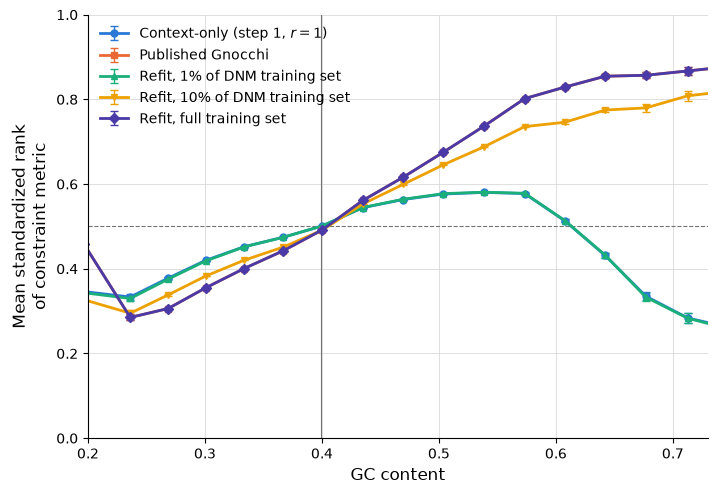

In [3]:
DISPLAY = {
    "step1_context_only": ("Context-only (step 1, $r{=}1$)", "#2a78d6", "o"),
    "step2_published":    ("Published Gnocchi",              "#eb6834", "s"),
    "dnm_1pct":           ("Refit, 1% of DNM training set",  "#1baf7a", "^"),
    "dnm_10pct":          ("Refit, 10% of DNM training set", "#eda100", "v"),
    "dnm_full":           ("Refit, full training set",       "#4a3aa7", "D"),
}

gc = binned["gc_mid"].to_numpy()
fig, ax = plt.subplots(figsize=(8, 5.5))
for label, _ in curves:
    display, color, marker = DISPLAY[label]
    ax.errorbar(gc, binned[f"mean_{label}"].to_numpy(), yerr=binned[f"se_{label}"].to_numpy(),
                 marker=marker, color=color, markersize=5, linewidth=2,
                 capsize=3, elinewidth=1, label=display)

ax.axhline(0.5, color="0.45", linewidth=0.8, linestyle="--")
ax.axvline(gc_mean, color="0.45", linewidth=0.8)
ax.set_xlim(XRANGE)
ax.set_ylim(0, 1)
ax.set_xlabel("GC content", fontsize=12)
ax.set_ylabel("Mean standardized rank\nof constraint metric", fontsize=12)
ax.grid(True, color="0.85", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(fontsize=10, frameon=False, loc="upper left")

fig.savefig(os.path.join(OUTPUT_DIR, "dnm_training_set_size_bias.pdf"), bbox_inches="tight")
print("wrote", os.path.join(OUTPUT_DIR, "dnm_training_set_size_bias.pdf"))

## Feature selection by training-set size

A second, independent line of evidence for the same mechanism: how often `GC_content` itself clears
Bonferroni significance, as a function of training-set size. At 1% it is selected in **no** context —
the model has no statistical power to detect a GC effect to adjust for, whatever the true relationship
is. These tables are written by `-mode refit`.

In [4]:
import pandas as pd

rows = []
for label, tag in [("dnm_1pct", "frac0.01_seed0"), ("dnm_10pct", "frac0.1_seed0"), ("dnm_full", "full")]:
    path = os.path.join(OUTPUT_DIR, f"selected.dnm_refit_{tag}.txt")
    if not os.path.exists(path):
        continue
    sel = pd.read_csv(path, sep="\t")
    rows.append({
        "training set": label,
        "contexts with any selected feature": sel["context"].nunique(),
        "contexts selecting GC_content": sel[sel["feature"] == "GC_content"]["context"].nunique(),
        "total (context, feature) rows": len(sel),
    })
pd.DataFrame(rows)

,training set,contexts with any selected feature,contexts selecting GC_content,"total (context, feature) rows"
0,dnm_1pct,4,0,4
1,dnm_10pct,21,7,55
2,dnm_full,32,23,239
